# Experiment 1 - ANN for Regression
**Name:** Mohamed Aashik S

**Roll No:** 24BAD072

In [ ]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:

# Load Dataset
X, y = fetch_california_housing(return_X_y=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:

# Build ANN
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-31 08:34:42.529117: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0051 - mae: 0.6477 - val_loss: 0.4688 - val_mae: 0.4923
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4106 - mae: 0.4561 - val_loss: 0.4833 - val_mae: 0.4770
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3872 - mae: 0.4396 - val_loss: 0.4114 - val_mae: 0.4637
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3622 - mae: 0.4273 - val_loss: 0.3827 - val_mae: 0.4369
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3469 - mae: 0.4166 - val_loss: 0.3755 - val_mae: 0.4376
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3423 - mae: 0.4119 - val_loss: 0.3627 - val_mae: 0.4202
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3262 - mae: 0.4013 - val_loss: 0.3472 - val_mae: 0.4115
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3206 - mae: 0.3966 - val_loss: 0.3444 - val_mae: 0.4071
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3152 

In [ ]:

# Prediction
pred = model.predict(X_test)


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:

# Evaluation
mse = mean_squared_error(y_test, pred)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)


MSE: 0.2959730987436435
MAE: 0.3680942787649869
RMSE: 0.5440340970413927


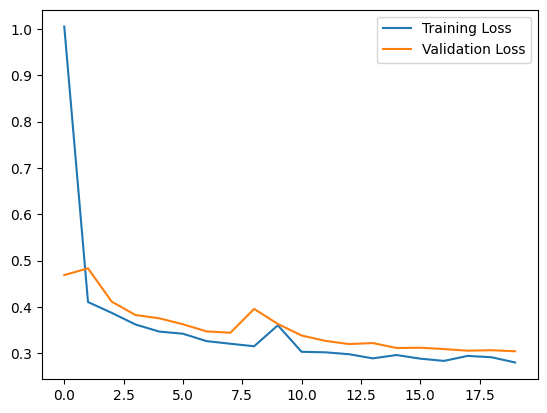

In [ ]:

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()